In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression
from joblib import Parallel, delayed

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents
from circuits import CPCircuit

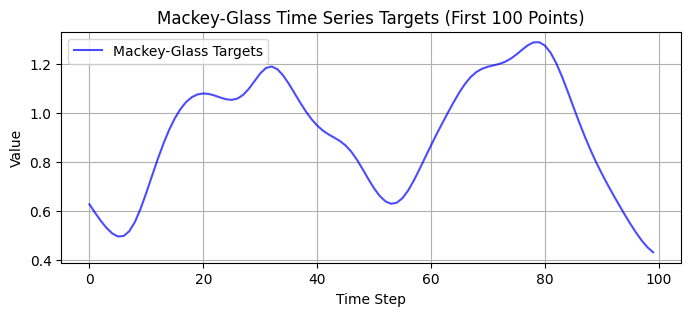

In [3]:
window_size = 20
n_samples = 10000
tau = 17
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = tau, window_size=window_size,prediction_horizon=20, plot=True)

In [4]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train_, X_test_ = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_)
X_test = scaler.transform(X_test_) 

In [6]:
itr = 20
a = 0.00001
b = 1
alphas = np.linspace(a,b,itr)

In [7]:
def evaluate_alpha(i, X_train, y_train, X_test, y_test, alphas):
    try:
        dim = len(X_train[0])
        CP_params = [0.1499956344663278, np.pi/7, -np.pi/3, 7*np.pi/7, np.pi/9, -np.pi/7]

        cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
        esn = ESNetwork(
            reservoir=cprc,
            dim=dim,
            regularization=1e-6,
            alpha=alphas[i],
            show_progress=False,
            approach='feedback',
            model_type='ridge',
            limit=0.2,
            cpk=True
        )

        esn.fit(X_train, y_train)
        predictions = esn.predict(X_test)
        rmse = mean_squared_error(y_test, predictions)
        return rmse

    except Exception as e:
        return f"Error at index {i}: {e}"


In [8]:
itr = len(alphas)

mserror2 = Parallel(n_jobs=-1)(
    delayed(evaluate_alpha)(i, X_train, y_train, X_test, y_test, alphas)
    for i in range(itr)
)

In [9]:
for i, result in enumerate(mserror2):
    if isinstance(result, float):
        print(f"Alpha {alphas[i]:.3f} → RMSE: {result:.4f}")
    else:
        print(result)

Alpha 0.000 → RMSE: 0.0002
Alpha 0.053 → RMSE: 0.0001
Alpha 0.105 → RMSE: 0.0000
Alpha 0.158 → RMSE: 0.0000
Alpha 0.211 → RMSE: 0.0000
Alpha 0.263 → RMSE: 0.0000
Alpha 0.316 → RMSE: 0.0000
Alpha 0.368 → RMSE: 0.0000
Alpha 0.421 → RMSE: 0.0000
Alpha 0.474 → RMSE: 0.0000
Alpha 0.526 → RMSE: 0.0000
Alpha 0.579 → RMSE: 0.0000
Alpha 0.632 → RMSE: 0.0000
Alpha 0.684 → RMSE: 0.0000
Alpha 0.737 → RMSE: 0.0000
Alpha 0.789 → RMSE: 0.0000
Alpha 0.842 → RMSE: 0.0000
Alpha 0.895 → RMSE: 0.0000
Alpha 0.947 → RMSE: 0.0000
Alpha 1.000 → RMSE: 0.0000


In [ ]:
itr = len(alphas)

mserror2 = Parallel(n_jobs=-1)(
    delayed(evaluate_alpha)(i, X_train, y_train, X_test, y_test, alphas)
    for i in range(itr)
)


In [15]:
import pandas as pd
df = pd.DataFrame([mserror2], columns=[f"mse_{i}" for i in range(len(mserror2))])
df.insert(0, "tau", tau) 
df.to_csv(f"../Paper_results/mse_alpha_{tau}_normalized.csv", index=False)

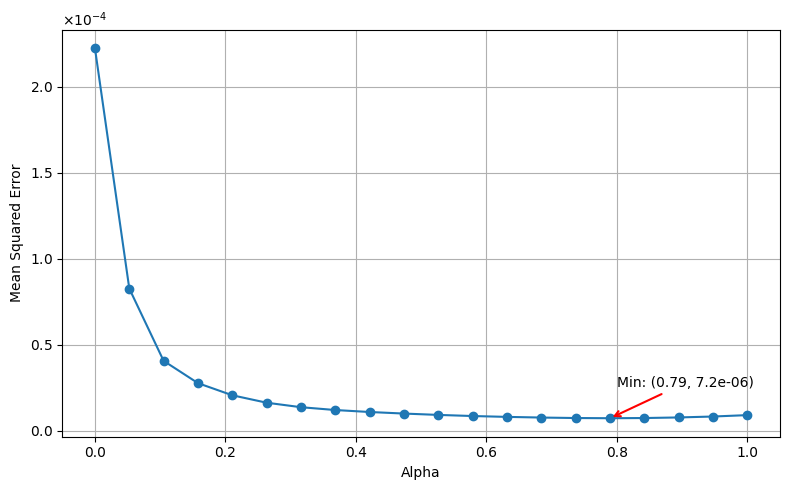

In [28]:
import matplotlib.ticker as ticker
param_values = alphas  
errors = mserror2     

# Find the minimum
min_idx = np.argmin(errors)
min_alpha = param_values[min_idx]
min_mse = errors[min_idx]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(param_values, errors, marker='o', linestyle='-', label="MSE")

# Add arrow annotation
ax = plt.gca()
ax.annotate(
    f"Min: ({min_alpha:.2f}, {min_mse:.1e})",
    xy=(min_alpha, min_mse),             # point to annotate
    xytext=(min_alpha + 0.01, min_mse * 3.5),  # arrowhead to label position
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='red', linewidth=1.5),
    fontsize=10,
    ha='left'
)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
# Labels and grid
plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
# plt.title("Performance of Quantum Reservoir vs Alpha")
plt.grid(True)
plt.tight_layout()

plt.savefig("../Paper_results/figures/qrc_alpha_vs_mse.pdf")
plt.show()


In [29]:
np.pi

3.141592653589793